In [10]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"marynnipaameteku","key":"394dcd66df4685317b2d5bdfa2aa0b12"}'}

In [11]:
import os, shutil, pathlib

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# confirm connection
!kaggle datasets list | head

# download your TB dataset
!kaggle datasets download -d yasserhessein/tuberculosis-chest-x-rays-images

# unzip into a working folder
!unzip tuberculosis-chest-x-rays-images.zip -d tb-data

ref                                                             title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
wardabilal/spotify-global-music-dataset-20092025                Spotify Global Music Dataset (2009–2025)               1289021  2025-11-11 09:43:05.933000           3244         56  1.0              
sadiajavedd/students-academic-performance-dataset               Students_Academic_Performance_Dataset                     8907  2025-10-23 04:16:35.563000           9175        230  1.0              
zahranusrat/salary                                              Salary Insights by Job Role (2024)                      110295  2025-11-11 07:02:27.350000           1301         24  1.0              


In [12]:
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.19.0
GPU devices: []


In [13]:
# Inspect directory tree to find where "Normal" and "Tuberculosis" folders are
for root, dirs, files in os.walk("tb-data"):
    level = root.replace("tb-data", "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 2 * (level + 1)
    for d in dirs:
        print(f"{subindent}{d}/")
    break


tb-data/
  Dataset of Tuberculosis Chest X-rays Images/


In [14]:
import os, glob
import pandas as pd
from sklearn.model_selection import train_test_split

# Correct base + class folders
BASE_DIR   = "tb-data/Dataset of Tuberculosis Chest X-rays Images"
NORMAL_DIR = os.path.join(BASE_DIR, "Normal Chest X-rays")
TB_DIR     = os.path.join(BASE_DIR, "TB Chest X-rays")

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
SEED       = 42

print("BASE_DIR  :", BASE_DIR)
print("NORMAL_DIR:", NORMAL_DIR)
print("TB_DIR    :", TB_DIR)

BASE_DIR  : tb-data/Dataset of Tuberculosis Chest X-rays Images
NORMAL_DIR: tb-data/Dataset of Tuberculosis Chest X-rays Images/Normal Chest X-rays
TB_DIR    : tb-data/Dataset of Tuberculosis Chest X-rays Images/TB Chest X-rays


In [15]:
# 1) Collect image file paths
normal_files = glob.glob(os.path.join(NORMAL_DIR, "*.*"))
tb_files     = glob.glob(os.path.join(TB_DIR, "*.*"))

print("Found normal images:", len(normal_files))
print("Found TB images    :", len(tb_files))

# 2) Build DataFrame
df = pd.DataFrame({
    "filepath": normal_files + tb_files,
    "label":    ["normal"] * len(normal_files) + ["tb"] * len(tb_files)
})

# 3) Clean: keep only image files & ensure string dtype
df = df.dropna(subset=["filepath"]).copy()
df["filepath"] = df["filepath"].astype(str)
df = df[df["filepath"].str.lower().str.endswith(
    (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")
)].reset_index(drop=True)

print("\nTotal images after filtering:", len(df))
print(df["label"].value_counts())
df.head()

Found normal images: 514
Found TB images    : 2494

Total images after filtering: 3008
label
tb        2494
normal     514
Name: count, dtype: int64


,filepath,label
0,tb-data/Dataset of Tuberculosis Chest X-rays I...,normal
1,tb-data/Dataset of Tuberculosis Chest X-rays I...,normal
2,tb-data/Dataset of Tuberculosis Chest X-rays I...,normal
3,tb-data/Dataset of Tuberculosis Chest X-rays I...,normal
4,tb-data/Dataset of Tuberculosis Chest X-rays I...,normal


In [16]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print("Train:", train_df["label"].value_counts().to_dict())
print("Val  :",   val_df["label"].value_counts().to_dict())
print("Test :",  test_df["label"].value_counts().to_dict())


Train: {'tb': 1745, 'normal': 360}
Val  : {'tb': 374, 'normal': 77}
Test : {'tb': 375, 'normal': 77}


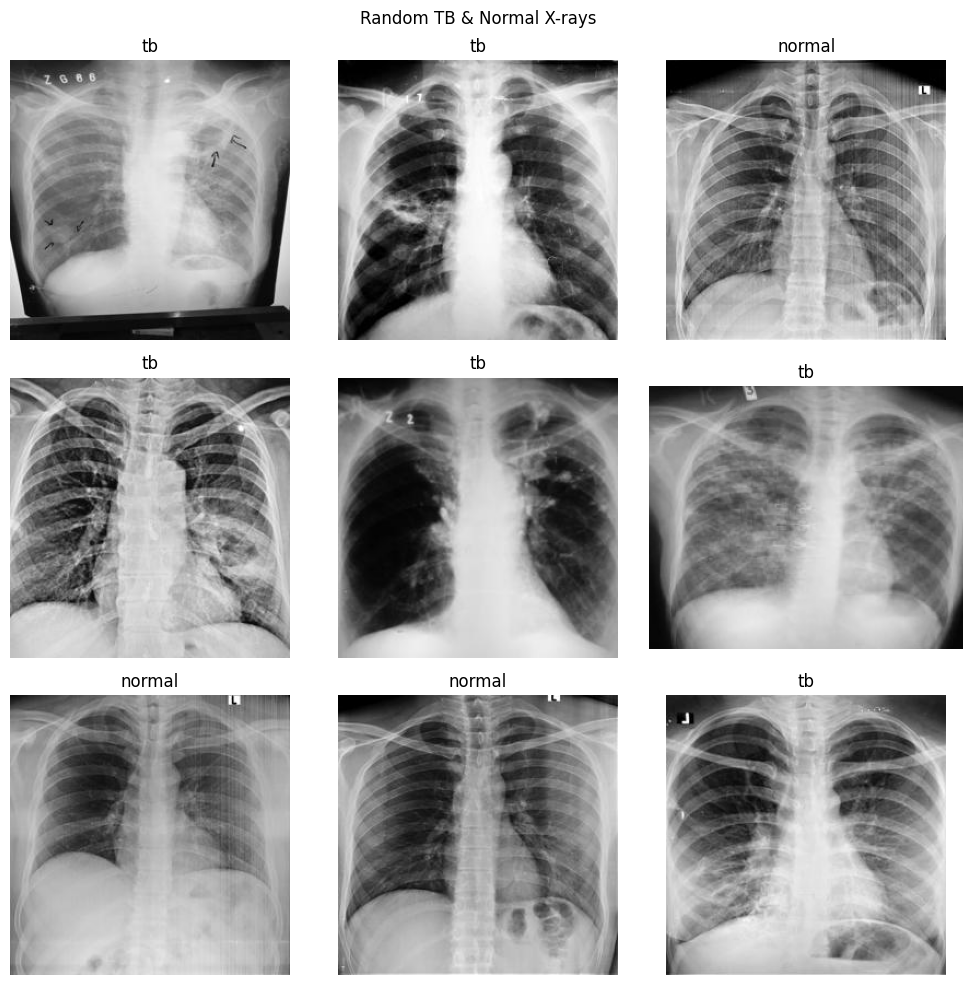

In [17]:
import cv2
import matplotlib.pyplot as plt

def show_random_images(df, n=9, title="Random Samples"):
    plt.figure(figsize=(10, 10))
    for i in range(n):
        row = df.sample(1).iloc[0]
        img = cv2.imread(row["filepath"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(3, 3, i+1)
        plt.imshow(img)
        plt.title(row["label"])
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_random_images(df, n=9, title="Random TB & Normal X-rays")


In [18]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_gen = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Class indices:", train_gen.class_indices)


Found 2105 validated image filenames belonging to 2 classes.
Found 451 validated image filenames belonging to 2 classes.
Found 452 validated image filenames belonging to 2 classes.
Class indices: {'normal': 0, 'tb': 1}


In [35]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SIZE + (3,)
)

# First phase: feature extraction only
base_model.trainable = False

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(
    128,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(1e-4)
)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs, outputs, name="tb_efficientnet_transfer")
model.summary()


Model: "tb_efficientnet_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [20]:
initial_lr = 1e-3  # matches proposal
optimizer = keras.optimizers.Adam(learning_rate=initial_lr)

model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


In [21]:
checkpoint_path = "tb_efficientnet_best.h5"

callbacks = [
    keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-5,
        verbose=1
    )
]


In [24]:
# Train the model using the training dataset and validate on the validation set
EPOCHS = 10

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8043 - loss: 0.5275
Epoch 1: val_loss improved from inf to 0.47638, saving model to tb_efficientnet_best.h5


66/66 ━━━━━━━━━━━━━━━━━━━━ 226s 3s/step - accuracy: 0.8047 - loss: 0.5271 - val_accuracy: 0.8293 - val_loss: 0.4764 - learning_rate: 0.0010
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8365 - loss: 0.4765
Epoch 2: val_loss did not improve from 0.47638
66/66 ━━━━━━━━━━━━━━━━━━━━ 225s 3s/step - accuracy: 0.8363 - loss: 0.4766 - val_accuracy: 0.8293 - val_loss: 0.4806 - learning_rate: 0.0010
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8196 - loss: 0.4996
Epoch 3: val_loss improved from 0.47638 to 0.47024, saving model to tb_efficientnet_best.h5


66/66 ━━━━━━━━━━━━━━━━━━━━ 206s 3s/step - accuracy: 0.8197 - loss: 0.4994 - val_accuracy: 0.8293 - val_loss: 0.4702 - learning_rate: 0.0010
Epoch 4/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8335 - loss: 0.4809
Epoch 4: val_loss improved from 0.47024 to 0.46973, saving model to tb_efficientnet_best.h5


66/66 ━━━━━━━━━━━━━━━━━━━━ 216s 3s/step - accuracy: 0.8334 - loss: 0.4811 - val_accuracy: 0.8293 - val_loss: 0.4697 - learning_rate: 0.0010
Epoch 5/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8301 - loss: 0.4818
Epoch 5: val_loss improved from 0.46973 to 0.46752, saving model to tb_efficientnet_best.h5


66/66 ━━━━━━━━━━━━━━━━━━━━ 217s 3s/step - accuracy: 0.8300 - loss: 0.4818 - val_accuracy: 0.8293 - val_loss: 0.4675 - learning_rate: 0.0010
Epoch 6/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8338 - loss: 0.4855
Epoch 6: val_loss improved from 0.46752 to 0.46709, saving model to tb_efficientnet_best.h5


66/66 ━━━━━━━━━━━━━━━━━━━━ 210s 3s/step - accuracy: 0.8338 - loss: 0.4856 - val_accuracy: 0.8293 - val_loss: 0.4671 - learning_rate: 0.0010
Epoch 7/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8282 - loss: 0.4811
Epoch 7: val_loss did not improve from 0.46709
66/66 ━━━━━━━━━━━━━━━━━━━━ 218s 3s/step - accuracy: 0.8282 - loss: 0.4811 - val_accuracy: 0.8293 - val_loss: 0.4701 - learning_rate: 0.0010
Epoch 8/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8282 - loss: 0.4859
Epoch 8: val_loss improved from 0.46709 to 0.46469, saving model to tb_efficientnet_best.h5


66/66 ━━━━━━━━━━━━━━━━━━━━ 218s 3s/step - accuracy: 0.8282 - loss: 0.4858 - val_accuracy: 0.8293 - val_loss: 0.4647 - learning_rate: 0.0010
Epoch 9/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8083 - loss: 0.5151
Epoch 9: val_loss did not improve from 0.46469
66/66 ━━━━━━━━━━━━━━━━━━━━ 206s 3s/step - accuracy: 0.8086 - loss: 0.5146 - val_accuracy: 0.8293 - val_loss: 0.4673 - learning_rate: 0.0010
Epoch 10/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8394 - loss: 0.4663
Epoch 10: val_loss did not improve from 0.46469

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
66/66 ━━━━━━━━━━━━━━━━━━━━ 205s 3s/step - accuracy: 0.8392 - loss: 0.4666 - val_accuracy: 0.8293 - val_loss: 0.4778 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 8.


In [26]:
# Unfreeze some of the top layers of the base model
base_model.trainable = True

fine_tune_at = int(len(base_model.layers) * 0.7)  # freeze bottom ~70%

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_ft = model.fit(
    train_gen,
    epochs=10,  # extra epochs for fine-tuning
    validation_data=val_gen,
    callbacks=callbacks
)


Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8223 - loss: 0.5227
Epoch 1: val_loss improved from 0.46469 to 0.46461, saving model to tb_efficientnet_best.h5


66/66 ━━━━━━━━━━━━━━━━━━━━ 310s 4s/step - accuracy: 0.8223 - loss: 0.5226 - val_accuracy: 0.8293 - val_loss: 0.4646 - learning_rate: 1.0000e-04
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8260 - loss: 0.4672
Epoch 2: val_loss did not improve from 0.46461
66/66 ━━━━━━━━━━━━━━━━━━━━ 274s 4s/step - accuracy: 0.8261 - loss: 0.4669 - val_accuracy: 0.8293 - val_loss: 0.4656 - learning_rate: 1.0000e-04
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8455 - loss: 0.3676
Epoch 3: val_loss improved from 0.46461 to 0.46438, saving model to tb_efficientnet_best.h5


66/66 ━━━━━━━━━━━━━━━━━━━━ 272s 4s/step - accuracy: 0.8457 - loss: 0.3675 - val_accuracy: 0.8293 - val_loss: 0.4644 - learning_rate: 1.0000e-04
Epoch 4/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8722 - loss: 0.3469
Epoch 4: val_loss did not improve from 0.46438
66/66 ━━━━━━━━━━━━━━━━━━━━ 323s 4s/step - accuracy: 0.8723 - loss: 0.3466 - val_accuracy: 0.8293 - val_loss: 0.4753 - learning_rate: 1.0000e-04
Epoch 5/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8698 - loss: 0.3265
Epoch 5: val_loss did not improve from 0.46438

Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
66/66 ━━━━━━━━━━━━━━━━━━━━ 273s 4s/step - accuracy: 0.8699 - loss: 0.3266 - val_accuracy: 0.8293 - val_loss: 0.6277 - learning_rate: 1.0000e-04
Epoch 6/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8838 - loss: 0.2983
Epoch 6: val_loss improved from 0.46438 to 0.34434, saving model to tb_efficientnet_best.h5


66/66 ━━━━━━━━━━━━━━━━━━━━ 276s 4s/step - accuracy: 0.8839 - loss: 0.2982 - val_accuracy: 0.8492 - val_loss: 0.3443 - learning_rate: 5.0000e-05
Epoch 7/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8975 - loss: 0.2777
Epoch 7: val_loss did not improve from 0.34434
66/66 ━━━━━━━━━━━━━━━━━━━━ 275s 4s/step - accuracy: 0.8975 - loss: 0.2775 - val_accuracy: 0.8293 - val_loss: 0.3475 - learning_rate: 5.0000e-05
Epoch 8/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8906 - loss: 0.2759
Epoch 8: val_loss did not improve from 0.34434

Epoch 8: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
66/66 ━━━━━━━━━━━━━━━━━━━━ 275s 4s/step - accuracy: 0.8908 - loss: 0.2757 - val_accuracy: 0.8293 - val_loss: 0.5043 - learning_rate: 5.0000e-05
Epoch 9/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8978 - loss: 0.2662
Epoch 9: val_loss improved from 0.34434 to 0.17030, saving model to tb_efficientnet_best.h5


66/66 ━━━━━━━━━━━━━━━━━━━━ 275s 4s/step - accuracy: 0.8978 - loss: 0.2661 - val_accuracy: 0.8980 - val_loss: 0.1703 - learning_rate: 2.5000e-05
Epoch 10/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9124 - loss: 0.2416
Epoch 10: val_loss improved from 0.17030 to 0.10527, saving model to tb_efficientnet_best.h5


66/66 ━━━━━━━━━━━━━━━━━━━━ 286s 4s/step - accuracy: 0.9124 - loss: 0.2417 - val_accuracy: 0.9889 - val_loss: 0.1053 - learning_rate: 2.5000e-05
Restoring model weights from the end of the best epoch: 10.


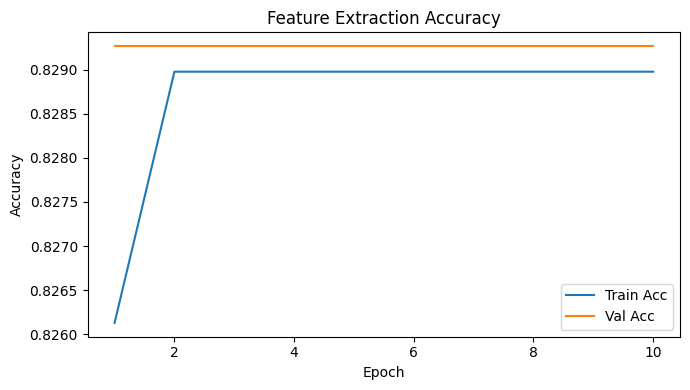

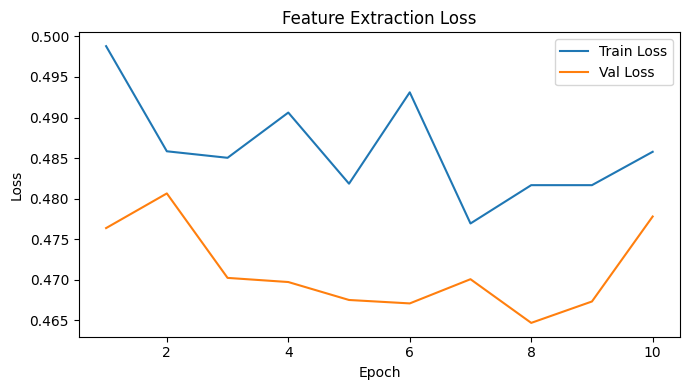

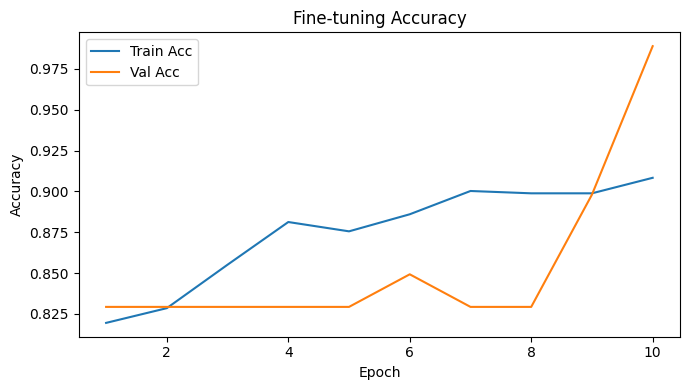

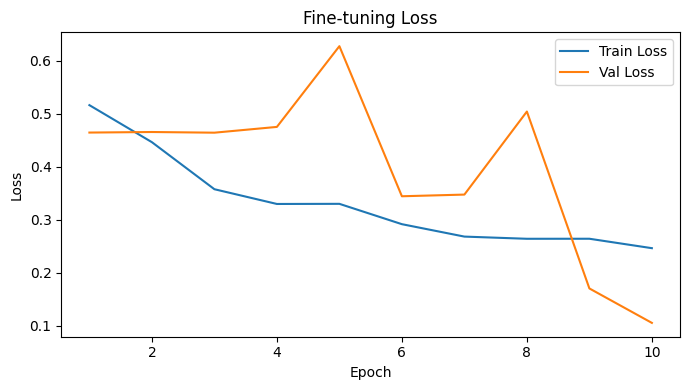

In [27]:
import matplotlib.pyplot as plt

def plot_history(hist, title_prefix=""):
    acc = hist.history.get("accuracy", [])
    val_acc = hist.history.get("val_accuracy", [])
    loss = hist.history.get("loss", [])
    val_loss = hist.history.get("val_loss", [])

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(7,4))
    plt.plot(epochs, acc, label="Train Acc")
    plt.plot(epochs, val_acc, label="Val Acc")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7,4))
    plt.plot(epochs, loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Val Loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_history(history, "Feature Extraction")

try:
    plot_history(history_ft, "Fine-tuning")
except NameError:
    pass

In [29]:
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve
)
import numpy as np

# Load best saved weights
model.load_weights(checkpoint_path)

# Predict on test set
test_gen.reset()
y_prob = model.predict(test_gen).ravel()
y_pred = (y_prob >= 0.5).astype(int)

# True labels
y_true = test_gen.classes
class_indices = test_gen.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}
print("Class mapping:", idx_to_class)

# Metrics
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec  = recall_score(y_true, y_pred, zero_division=0)
f1   = f1_score(y_true, y_pred, zero_division=0)

print(f"Test Accuracy : {acc:.4f}")
print(f"Precision     : {prec:.4f}")
print(f"Recall        : {rec:.4f}")
print(f"F1-score      : {f1:.4f}")

# ROC-AUC
try:
    auc = roc_auc_score(y_true, y_prob)
    print(f"ROC-AUC       : {auc:.4f}")
except Exception as e:
    print("ROC-AUC could not be computed:", e)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


15/15 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step
Class mapping: {0: 'normal', 1: 'tb'}
Test Accuracy : 0.9934
Precision     : 1.0000
Recall        : 0.9920
F1-score      : 0.9960
ROC-AUC       : 0.9994


Dataset URL: https://www.kaggle.com/datasets/yasserhessein/tuberculosis-chest-x-rays-images
License(s): CC-BY-SA-4.0
Found 452 validated image filenames belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


15/15 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step
Class mapping: {0: 'normal', 1: 'tb'}
Confusion Matrix:
 [[ 77   0]
 [  3 372]]


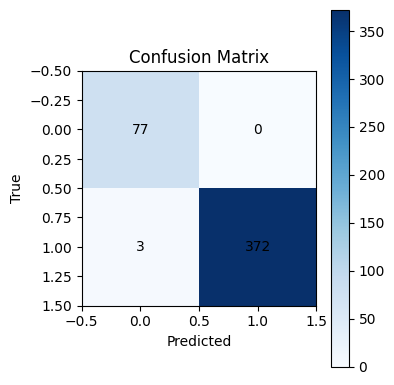


Classification Report:

              precision    recall  f1-score   support

      normal       0.96      1.00      0.98        77
          tb       1.00      0.99      1.00       375

    accuracy                           0.99       452
   macro avg       0.98      1.00      0.99       452
weighted avg       0.99      0.99      0.99       452



In [30]:
from sklearn.metrics import (
    confusion_matrix, classification_report
)
import numpy as np
import matplotlib.pyplot as plt
import os, glob
import pandas as pd
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Ensure Kaggle API key is set up and download the dataset
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d yasserhessein/tuberculosis-chest-x-rays-images -q
!unzip -o tuberculosis-chest-x-rays-images.zip -d tb-data > /dev/null


BASE_DIR   = "tb-data/Dataset of Tuberculosis Chest X-rays Images"
NORMAL_DIR = os.path.join(BASE_DIR, "Normal Chest X-rays")
TB_DIR     = os.path.join(BASE_DIR, "TB Chest X-rays")
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
SEED       = 42

# Dataframe creation
normal_files = glob.glob(os.path.join(NORMAL_DIR, "*.*"))
tb_files     = glob.glob(os.path.join(TB_DIR, "*.*"))
df = pd.DataFrame({
    "filepath": normal_files + tb_files,
    "label":    ["normal"] * len(normal_files) + ["tb"] * len(tb_files)
})
df = df.dropna(subset=["filepath"]).copy()
df["filepath"] = df["filepath"].astype(str)
df = df[df["filepath"].str.lower().str.endswith(
    (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")
)].reset_index(drop=True)


train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

val_test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False
)
tl_test_gen = test_gen # Renaming to match usage in this cell

# Model definition
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SIZE + (3,)
)


base_model.trainable = False

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(
    128,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(1e-4)
)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs, name="tb_efficientnet_transfer")

# Re-apply fine-tuning configuration
base_model.trainable = True
fine_tune_at = int(len(base_model.layers) * 0.7)
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Compile model with fine-tuning learning rate
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

checkpoint_path = "tb_efficientnet_best.h5"


# Load best saved weights (assuming checkpoint_path is defined globally or in an earlier cell)
model.load_weights(checkpoint_path)

# Predict on test set
tl_test_gen.reset()
y_prob = model.predict(tl_test_gen).ravel()
y_pred = (y_prob >= 0.5).astype(int)

# True labels
y_true = tl_test_gen.classes
class_indices = tl_test_gen.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}
print("Class mapping:", idx_to_class)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(4,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
for (i, j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha="center", va="center")
plt.colorbar()
plt.tight_layout()
plt.show()

# Detailed classification report
print("\nClassification Report:\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=[idx_to_class[0], idx_to_class[1]],
    zero_division=0
))


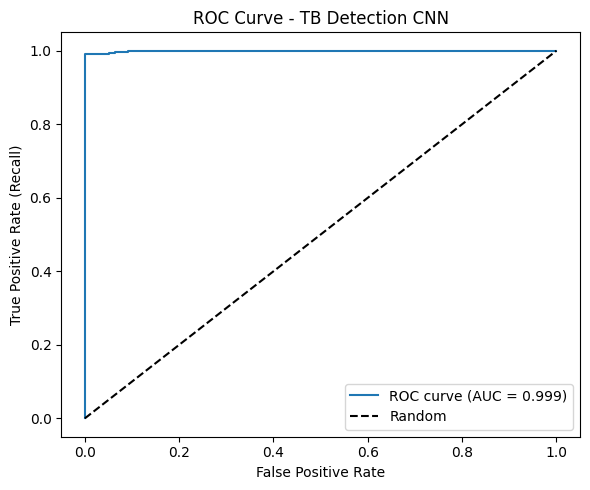

In [31]:
fpr, tpr, thresholds = roc_curve(y_true, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - TB Detection CNN")
plt.legend()
plt.tight_layout()
plt.show()


In [32]:
model.save("tb_efficientnet_transfer_cnn.h5")
print("Saved model as tb_efficientnet_transfer_cnn.h5")


Saved model as tb_efficientnet_transfer_cnn.h5
